In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [12]:
# 1. Load clean datasets
loans = pd.read_csv('../cleanData/clean_loan.csv', sep=';')
orders = pd.read_csv('../cleanData/clean_order.csv', sep=';')

# 2. Standardize join keys as strings
loans['account_id'] = loans['account_id'].astype(str)
loans['loan_id'] = loans['loan_id'].astype(str)
orders['account_id'] = orders['account_id'].astype(str)
orders['order_id'] = orders['order_id'].astype(str)

# 3. Filter out leasing immediately
orders = orders[orders['payment_type'].str.lower().str.strip() != 'leasing'].copy()

# 4. Check overlap & summary
loan_accounts = set(loans['account_id'])
order_accounts = set(orders['account_id'])

print(f"Total loans: {len(loans)}")
print(f"Total standing orders (excluding leasing): {len(orders):,}")
print(f"Loan accounts with at least one order: {len(loan_accounts.intersection(order_accounts))} / {len(loan_accounts)}")
print(f"Loan accounts with zero orders: {len(loan_accounts - order_accounts)}")

orders.head()

Total loans: 682
Total standing orders (excluding leasing): 6,130
Loan accounts with at least one order: 682 / 682
Loan accounts with zero orders: 0


,order_id,account_id,amount,payment_type
0,29401,1,2452.0,household_utility
1,29402,2,3372.7,loan_payment
2,29403,2,7266.0,household_utility
3,29404,3,1135.0,household_utility
4,29405,3,327.0,other_unknown


In [13]:
# 1. Aggregate total monthly commitment and order count
order_summary = orders.groupby('account_id').agg(
    order_total_amount=('amount', 'sum'),
    order_count=('order_id', 'count'),
    order_max_amount=('amount', 'max'),
    order_mean_amount=('amount', 'mean')
)

order_category_amounts = orders.pivot_table(
    index='account_id',
    columns='payment_type',
    values='amount',
    aggfunc='sum',
    fill_value=0
)
order_category_amounts.columns = [f'order_amt_{col.strip().lower()}' for col in order_category_amounts.columns]



# 3. Combine summary and category breakdowns
order_features = order_summary.join(order_category_amounts).fillna(0)

print(f"Total distinct accounts with engineered order features: {len(order_features)}")
order_features.head()

Total distinct accounts with engineered order features: 3626


,order_total_amount,order_count,order_max_amount,order_mean_amount,order_amt_household_utility,order_amt_insurance_payment,order_amt_loan_payment,order_amt_other_unknown
account_id,,,,,,,,
1,2452.0,1,2452.0,2452.0,2452.0,0.0,0.0,0.0
10,7033.0,1,7033.0,7033.0,7033.0,0.0,0.0,0.0
100,7927.0,2,7329.0,3963.5,598.0,0.0,0.0,7329.0
1000,7506.0,3,3179.0,2502.0,3179.0,2852.0,0.0,1475.0
10001,529.0,1,529.0,529.0,0.0,0.0,529.0,0.0


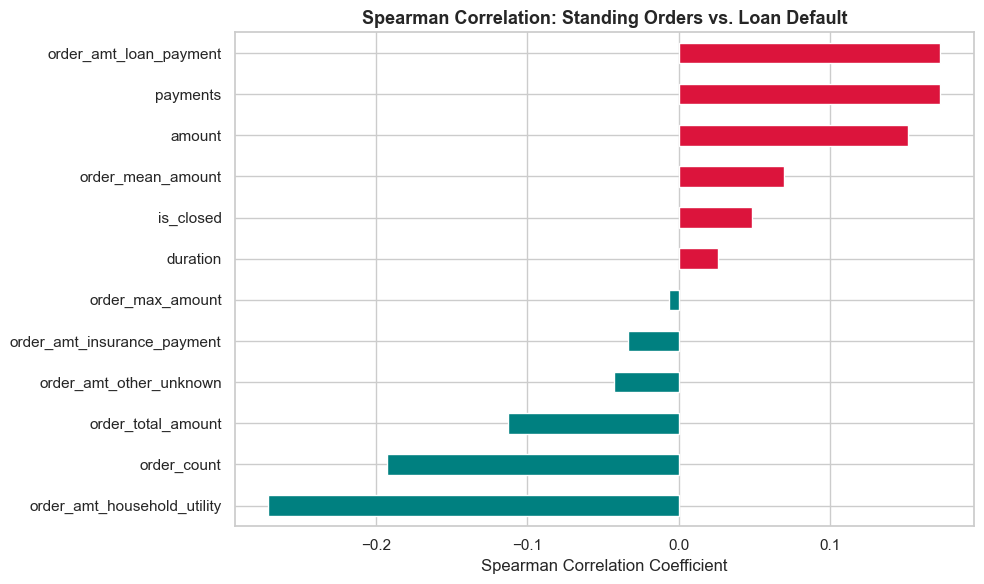


--- Exact Correlation Values ---
order_amt_household_utility   -0.271265
order_count                   -0.192879
order_total_amount            -0.113181
order_amt_other_unknown       -0.043004
order_amt_insurance_payment   -0.033780
order_max_amount              -0.006142
duration                       0.025705
is_closed                      0.048327
order_mean_amount              0.069726
amount                         0.151322
payments                       0.173014
order_amt_loan_payment         0.173038
target                         1.000000
Name: target, dtype: float64


In [14]:
# Left join onto loans (accounts with no standing orders receive 0)
loan_orders = loans.merge(order_features, on='account_id', how='left').fillna(0)

# Spearman correlation against default target
numeric_cols = loan_orders.select_dtypes(include=[np.number]).columns
order_corr = loan_orders[numeric_cols].corr(method='spearman')['target'].sort_values()

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
order_corr.drop('target').plot(
    kind='barh',
    color=np.where(order_corr.drop('target') > 0, 'crimson', 'teal')
)
plt.title('Spearman Correlation: Standing Orders vs. Loan Default', fontsize=13, fontweight='bold')
plt.xlabel('Spearman Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\n--- Exact Correlation Values ---")
print(order_corr)

--- Mean Monthly Standing Orders by Target ---
target                                 0            1
order_total_amount           9174.126898  7641.334211
order_count                     2.282178     1.710526
order_amt_household_utility  3891.457096  1012.368421
order_amt_insurance_payment   273.755776   218.776316
order_amt_loan_payment       4047.600495  5331.373684
order_amt_other_unknown       961.313531  1078.815789


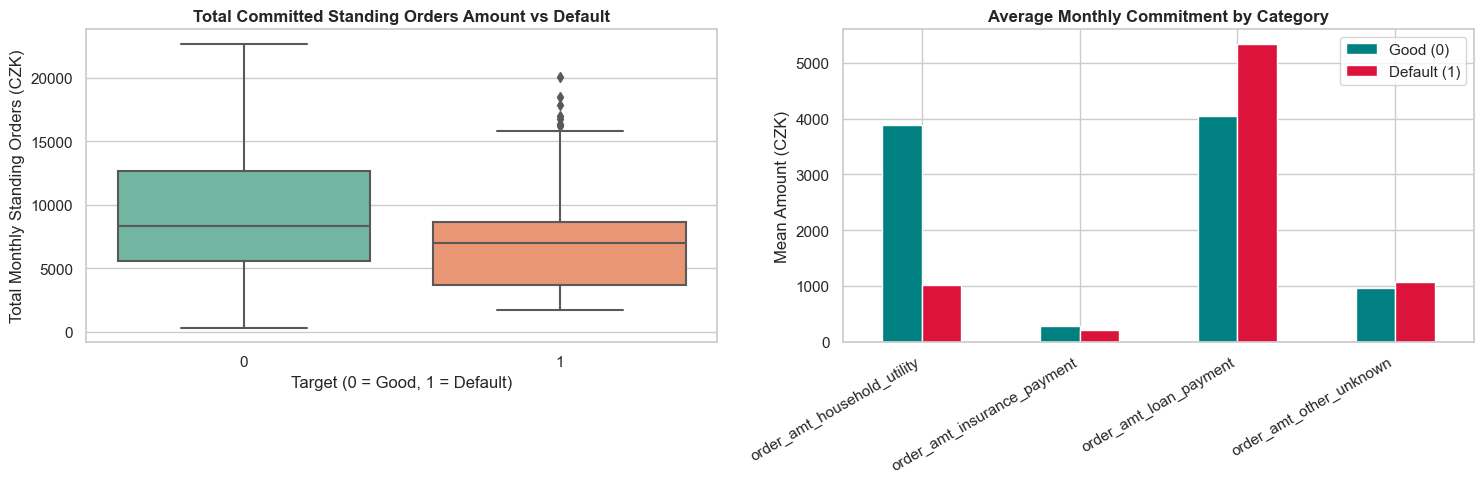

In [15]:
# 1. Inspect mean commitments by payment type between Good vs Default loans
category_cols = [c for c in order_category_amounts.columns if c in loan_orders.columns]

print("--- Mean Monthly Standing Orders by Target ---")
print(loan_orders.groupby('target')[['order_total_amount', 'order_count'] + category_cols].mean().T)

# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Total committed orders vs Target
sns.boxplot(
    data=loan_orders, 
    x='target', 
    y='order_total_amount', 
    palette='Set2', 
    ax=axes[0]
)
axes[0].set_title('Total Committed Standing Orders Amount vs Default', fontweight='bold')
axes[0].set_xlabel('Target (0 = Good, 1 = Default)')
axes[0].set_ylabel('Total Monthly Standing Orders (CZK)')

# Plot B: Breakdown by individual payment category
if category_cols:
    loan_orders.groupby('target')[category_cols].mean().T.plot(
        kind='bar',
        ax=axes[1],
        color=['teal', 'crimson']
    )
    axes[1].set_title('Average Monthly Commitment by Category', fontweight='bold')
    axes[1].set_ylabel('Mean Amount (CZK)')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
    axes[1].legend(['Good (0)', 'Default (1)'])

plt.tight_layout()
plt.show()

In [17]:
# 1. Set index to loan_id for standardized relational joins
if 'loan_id' in loan_orders.columns:
    loan_orders.set_index('loan_id', inplace=True)

# 2. Select only the newly engineered order features (excluding raw loan metadata/target)
features_to_export = list(order_features.columns)
order_export = loan_orders[features_to_export]

# 3. Export to modelData folder
output_dir = '../modelData'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'features_orders.csv')
order_export.to_csv(output_path)

print(f"Orders feature table saved to: {output_path}")
print(f"Shape: {order_export.shape}")
print(f"Exported features ({len(features_to_export)}): {features_to_export}")

Orders feature table saved to: ../modelData\features_orders.csv
Shape: (682, 8)
Exported features (8): ['order_total_amount', 'order_count', 'order_max_amount', 'order_mean_amount', 'order_amt_household_utility', 'order_amt_insurance_payment', 'order_amt_loan_payment', 'order_amt_other_unknown']
